In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, accuracy_score)
import joblib
import warnings
warnings.filterwarnings('ignore')

# File is actually CSV despite .xls extension
df = pd.read_csv('heart.xls')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nClass distribution:")
print(df['target'].value_counts())
df.head()

Shape: (1025, 14)

Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Class distribution:
target
1    526
0    499
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


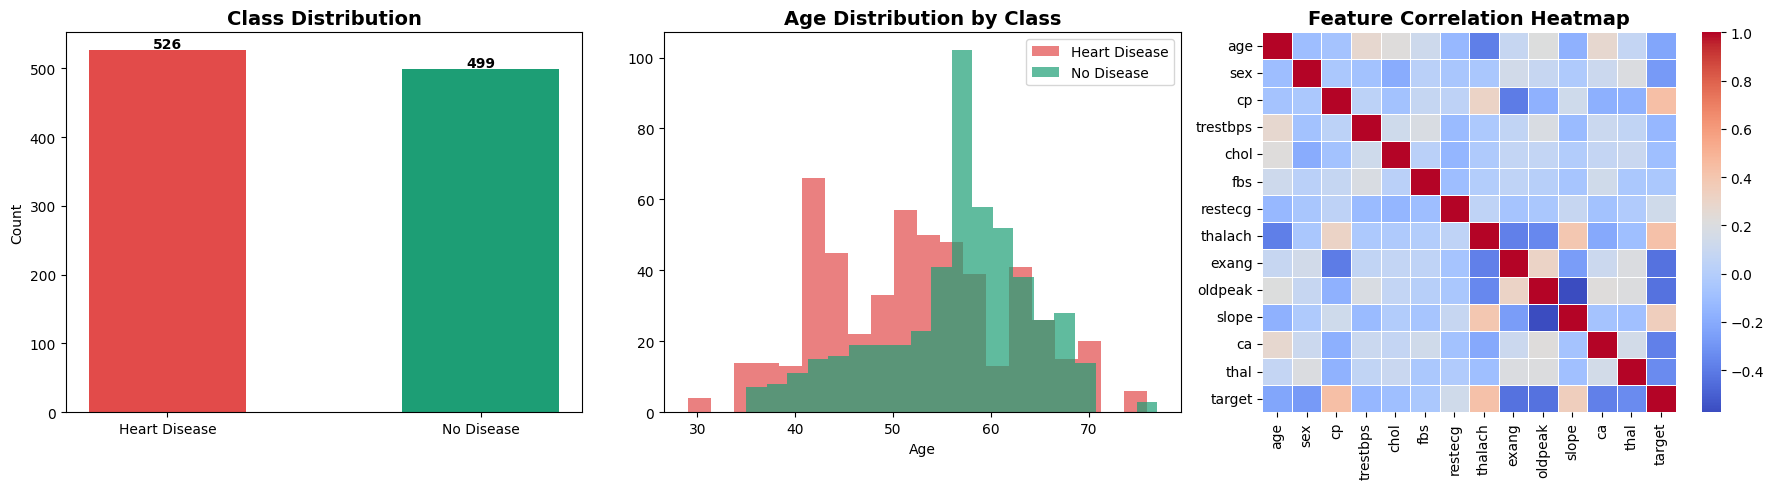

EDA complete.


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Class distribution
counts = df['target'].value_counts()
axes[0].bar(['Heart Disease', 'No Disease'], counts.values, color=['#E24B4A', '#1D9E75'], width=0.5)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

# 2. Age distribution by class
axes[1].hist(df[df['target']==1]['age'], bins=20, alpha=0.7, color='#E24B4A', label='Heart Disease')
axes[1].hist(df[df['target']==0]['age'], bins=20, alpha=0.7, color='#1D9E75', label='No Disease')
axes[1].set_title('Age Distribution by Class', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].legend()

# 3. Correlation heatmap
sns.heatmap(df.corr(), ax=axes[2], cmap='coolwarm', annot=False, linewidths=0.5)
axes[2].set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA complete.")

In [16]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")
print(f"Features         : {X_train.shape[1]}")

Training samples : 820
Testing samples  : 205
Features         : 13


In [17]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(probability=True, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred   = model.predict(X_test_sc)
    y_prob   = model.predict_proba(X_test_sc)[:, 1]
    cv_score = cross_val_score(model, X_train_sc, y_train, cv=5).mean()
    results[name] = {
        'model':    model,
        'accuracy': accuracy_score(y_test, y_pred),
        'roc_auc':  roc_auc_score(y_test, y_prob),
        'cv_score': cv_score,
        'y_pred':   y_pred,
        'y_prob':   y_prob
    }
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"  Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"  ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")
    print(f"  CV Score : {cv_score:.4f}")
    print(classification_report(y_test, y_pred, target_names=['No Disease', 'Heart Disease']))


  Logistic Regression
  Accuracy : 0.8098
  ROC-AUC  : 0.9298
  CV Score : 0.8439
               precision    recall  f1-score   support

   No Disease       0.89      0.70      0.78       100
Heart Disease       0.76      0.91      0.83       105

     accuracy                           0.81       205
    macro avg       0.82      0.81      0.81       205
 weighted avg       0.82      0.81      0.81       205


  Random Forest
  Accuracy : 1.0000
  ROC-AUC  : 1.0000
  CV Score : 0.9817
               precision    recall  f1-score   support

   No Disease       1.00      1.00      1.00       100
Heart Disease       1.00      1.00      1.00       105

     accuracy                           1.00       205
    macro avg       1.00      1.00      1.00       205
 weighted avg       1.00      1.00      1.00       205


  SVM
  Accuracy : 0.9268
  ROC-AUC  : 0.9771
  CV Score : 0.9122
               precision    recall  f1-score   support

   No Disease       0.94      0.91      0.92       

In [20]:
# Random Forest with constraints to prevent overfitting
rf_tuned = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,          # limit tree depth
    min_samples_split=10, # need 10 samples to split
    min_samples_leaf=4,   # need 4 samples at leaf
    random_state=42
)
rf_tuned.fit(X_train_sc, y_train)
y_pred_rf  = rf_tuned.predict(X_test_sc)
y_prob_rf  = rf_tuned.predict_proba(X_test_sc)[:, 1]
cv_rf      = cross_val_score(rf_tuned, X_train_sc, y_train, cv=5).mean()

print(f"Tuned Random Forest")
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"CV Score : {cv_rf:.4f}")
print(classification_report(y_test, y_pred_rf, target_names=['No Disease','Heart Disease']))

# Update results with tuned model
results['Random Forest'] = {
    'model':    rf_tuned,
    'accuracy': accuracy_score(y_test, y_pred_rf),
    'roc_auc':  roc_auc_score(y_test, y_prob_rf),
    'cv_score': cv_rf,
    'y_pred':   y_pred_rf,
    'y_prob':   y_prob_rf
}

Tuned Random Forest
Accuracy : 0.9220
ROC-AUC  : 0.9726
CV Score : 0.8878
               precision    recall  f1-score   support

   No Disease       0.97      0.87      0.92       100
Heart Disease       0.89      0.97      0.93       105

     accuracy                           0.92       205
    macro avg       0.93      0.92      0.92       205
 weighted avg       0.93      0.92      0.92       205



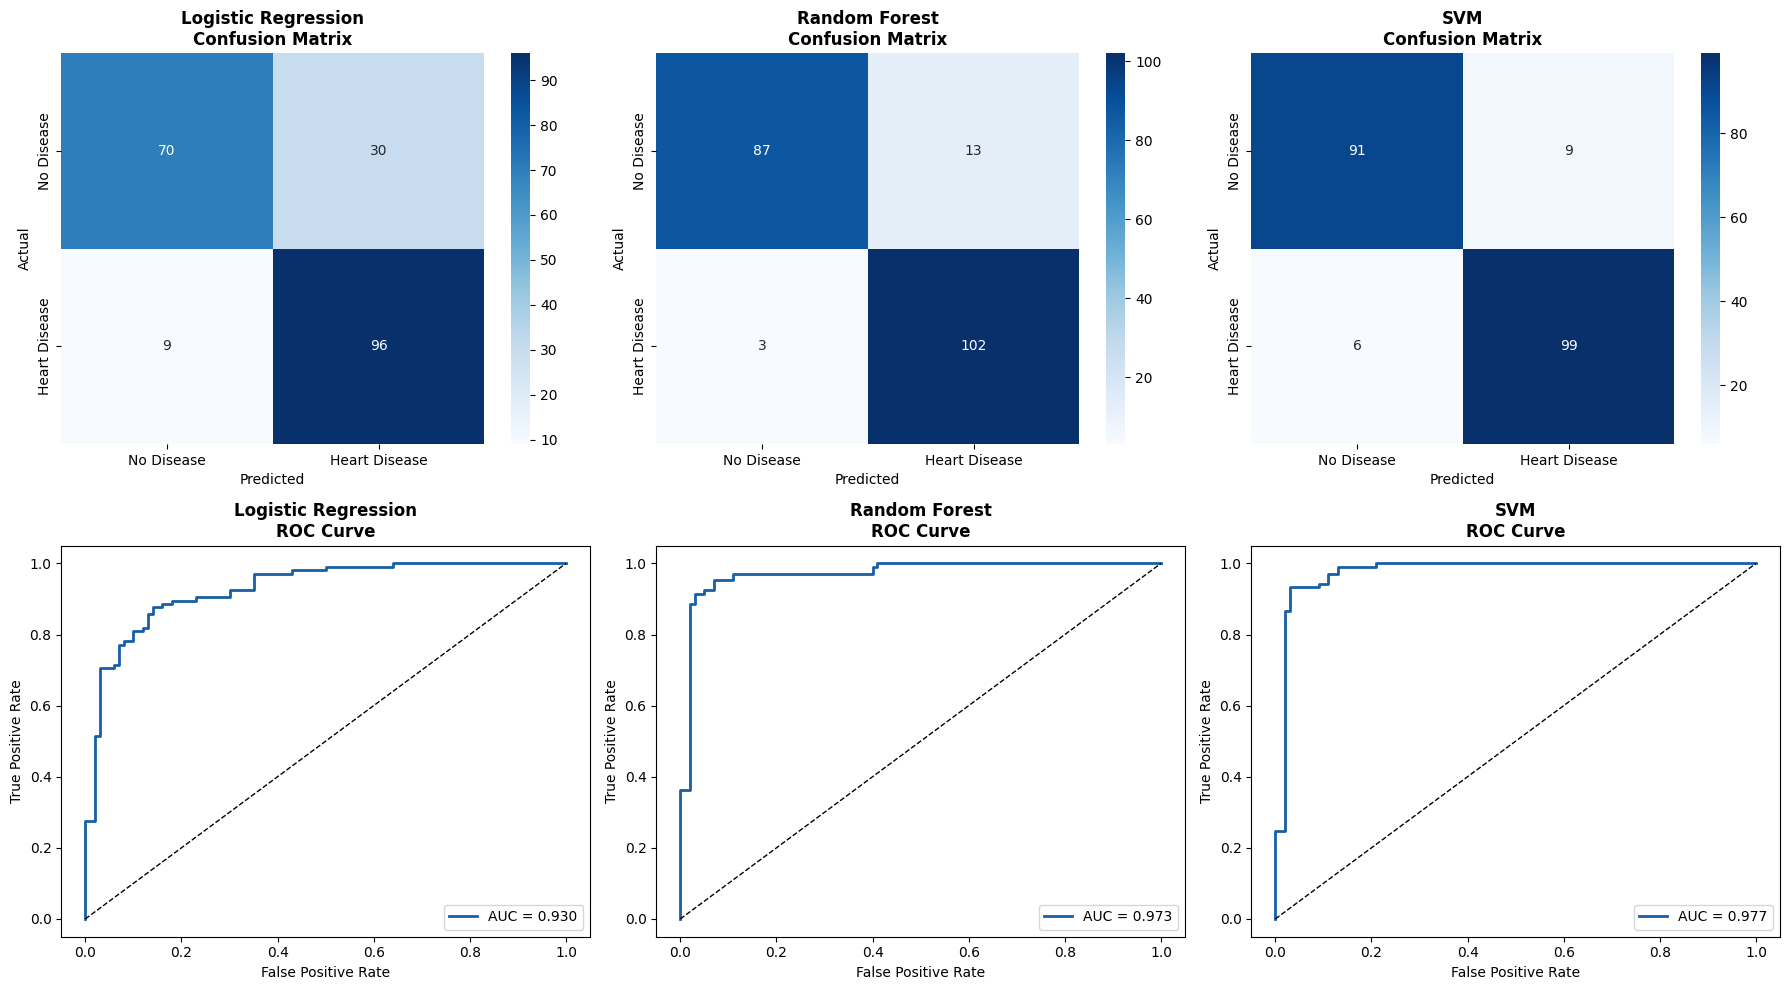


===== MODEL COMPARISON SUMMARY =====
                    Accuracy ROC-AUC CV Score
Logistic Regression   0.8098  0.9298   0.8439
Random Forest         0.9220  0.9726   0.8878
SVM                   0.9268  0.9771   0.9122


In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, (name, res) in enumerate(results.items()):
    # Confusion matrix
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0][i],
                xticklabels=['No Disease', 'Heart Disease'],
                yticklabels=['No Disease', 'Heart Disease'])
    axes[0][i].set_title(f'{name}\nConfusion Matrix', fontweight='bold')
    axes[0][i].set_ylabel('Actual')
    axes[0][i].set_xlabel('Predicted')

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    axes[1][i].plot(fpr, tpr, color='#185FA5', lw=2, label=f"AUC = {res['roc_auc']:.3f}")
    axes[1][i].plot([0,1],[0,1], 'k--', lw=1)
    axes[1][i].set_title(f'{name}\nROC Curve', fontweight='bold')
    axes[1][i].set_xlabel('False Positive Rate')
    axes[1][i].set_ylabel('True Positive Rate')
    axes[1][i].legend(loc='lower right')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print("\n===== MODEL COMPARISON SUMMARY =====")
summary = pd.DataFrame({
    name: {
        'Accuracy': f"{r['accuracy']:.4f}",
        'ROC-AUC':  f"{r['roc_auc']:.4f}",
        'CV Score': f"{r['cv_score']:.4f}"
    }
    for name, r in results.items()
}).T
print(summary)

In [22]:
best_name  = max(results, key=lambda k: results[k]['roc_auc'])
best_model = results[best_name]['model']
print(f"Best model: {best_name}  (ROC-AUC: {results[best_name]['roc_auc']:.4f})")

joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler,     'scaler.pkl')
print("Saved: best_model.pkl and scaler.pkl")

Best model: SVM  (ROC-AUC: 0.9771)
Saved: best_model.pkl and scaler.pkl
